### Imports and Setup

In [1]:
import itertools

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from tqdm.notebook import tqdm

from hnxwidget import HypernetxWidget
import hypernetx as hnx
import networkx as nx

from whale_gunshot_localization import config

### Generate Synthetic Measurements

Functions to randomly generate the measurements/sources/associations and visualize the results

In [2]:
def generate_measurements(num_sources, var=10, num_delete=0, seed=1111):
    """
    Generate some synthetic measurements to test with data association/localization algoritms.
    
    Parameters
    ----------
    num_sources : int
        maximum number of sources
    var : float
        variance of Gaussian noise added to range measurements
    num_delete : int
        maximum number of measurements to hide/delete at each TOSSIT
    seed : int
        seed for RNG
        
    Returns
    -------
    range_measurements : List[array-like]
        each sublist contains range measurements and is associated with a particular TOSSIT
    source_associations : List[array-like]
        same shape as range_measurements. each sublist contains numbers which associate the
        range_measurement in the corresponding spot in the data structure with a source.
    TOSSIT_association : List[array-like]
        same shape as range_measurements. each sublist contains numbers which associate the
        range_measurement in the corresponding spot in the data structure with a TOSSIT.    
    source_locs : array-like[array-like]
        matrix of generated source locations
    """ 
    
    # get TOSSIT locations and extreme coordinate values
    TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T
    min_x = config['scaling']['min_x']
    max_x = config['scaling']['max_x']
    min_y = config['scaling']['min_y']
    max_y = config['scaling']['max_y']
    max_r = config['scaling']['max_r']

    # instantiate random number generator
    rng = np.random.default_rng(seed)
    
    # choose number of sources
    n = rng.choice(np.arange(num_sources))

    # generate source locations
    source_locs = np.concatenate((rng.uniform(min_y, max_y, size=(n,1)), rng.uniform(min_x, max_x, size=(n,1))), axis=1)

    # range measurements and associations
    range_measurements = [(np.linalg.norm(source_locs - TOSSIT_locations[t,:], axis=1) + rng.normal(loc=0, scale=np.sqrt(var), size=n)) for t in range(TOSSIT_locations.shape[0])]
    source_associations = [(np.arange(n)) for _ in range(TOSSIT_locations.shape[0])]
    TOSSIT_associations = [np.ones((n,), dtype=int)*t for t in range(TOSSIT_locations.shape[0])]
    
    # generate number of measurements for each source to delete
    del_list = rng.choice(np.arange(num_delete+1), size=TOSSIT_locations.shape[0])
    
#     # delete measurements and associations
#     range_measurements_buff = np.asarray(list(itertools.zip_longest(range_measurements))).T
#     source_associations_buff = np.asarray(list(itertools.zip_longest(source_associations))).T
    
#     for a, d in zip(range(n), del_list):
#         if d:
#             idx_list = np.argwhere(source_associations_buff == a)
#             del_idx = rng.choice(len(idx_list), replace=False, size=d)
#             for i in del_idx:
#                 to_del = idx_list[i]
#                 range_measurements[to_del[0]] = np.delete(range_measurements[to_del[0]], to_del[1])
#                 source_associations[to_del[0]] = np.delete(source_associations[to_del[0]], to_del[1])
#                 TOSSIT_associations[to_del[0]] = np.delete(TOSSIT_associations[to_del[0]], to_del[1])
            
    
    for i, (m, a, t, d) in enumerate(zip(range_measurements, source_associations, TOSSIT_associations, del_list)):
        if d:
            del_idx = rng.choice(np.arange(n), replace=False, size=d)
            range_measurements[i] = np.delete(m, del_idx)
            source_associations[i] = np.delete(a, del_idx)
            TOSSIT_associations[i] = np.delete(t, del_idx)
    
    # make sure smallest association value is 0
    bias = min([a[0] for a in source_associations])
    if bias > 0:
        for i, a in enumerate(source_associations):
            source_associations[i] = a - bias
    
    return range_measurements, source_associations, TOSSIT_associations, source_locs

def visualize_collection(measurements, TOSSIT_associations, source_associations, source_locs):
    """
    Display the ground truth range measurements as lines connecting sources and sensors as well as
    the ground truth data associations which are denoted by color.
    
    Parameters
    ----------
    measurements : List[array-like]
        each sublist contains range measurements and is associated with a particular TOSSIT
    source_associations : List[array-like]
        same shape as range_measurements. each sublist contains numbers which associate the
        range_measurement in the corresponding spot in the data structure with a source.
    TOSSIT_association : List[array-like]
        same shape as range_measurements. each sublist contains numbers which associate the
        range_measurement in the corresponding spot in the data structure with a TOSSIT.    
    source_locs : array-like[array-like]
        matrix of generated source locations
    """
    
    # instantiate random number generator (used for color generation
    # only, so no need for custom seed)
    rng = np.random.default_rng(1111)
    
    # load TOSSIT locations
    TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T

    # plot sources and sensor locations
    plt.figure()
    plt.plot(TOSSIT_locations[:,1], TOSSIT_locations[:,0], '^', label='sensor', markersize=12, markeredgewidth=2)
    plt.plot(source_locs[:,1], source_locs[:,0], 'o', label='source')

    # get unique colors for each source
    color_list = [rng.uniform(0, 1, size=3) for _ in range(len(max(measurements, key=lambda x:len(x))))]
    # get group of measurements, associated TOSSITs, and associated sources
    for i, (m, t, a) in enumerate(zip(measurements, TOSSIT_associations, source_associations)):
        # for each measurement, draw line between associated TOSSIT and source
        for j, (mm, tt, aa) in enumerate(zip(m, t, a)):
            plt.plot([TOSSIT_locations[tt,1], source_locs[aa,1]], [TOSSIT_locations[tt,0], source_locs[aa,0]], '--', color=color_list[aa])
    
    # final touches on plot
    plt.gca().invert_yaxis()
    plt.xlabel("X [m]")
    plt.ylabel("Y [m]")
    plt.title("Ideal Measurements/Associations")
    plt.legend(["sensor", "source", "source range measurement"],bbox_to_anchor=(1.05, 1.0), loc='upper left')
    plt.show()

def visualize_measurements(measurements, TOSSIT_associations, source_associations, source_locs, buffer=10000, figsize=(5,20)):
    """
    Visualize actual noisey measurements using circles centered about the TOSSIT used to make the measurement as
    well as the ground truth data associations which are donoted by colors. Plots show each source individually
    as well as all of them aggregated together.
    
    Parameters
    ----------
    measurements : List[array-like]
        each sublist contains range measurements and is associated with a particular TOSSIT
    source_associations : List[array-like]
        same shape as range_measurements. each sublist contains numbers which associate the
        range_measurement in the corresponding spot in the data structure with a source.
    TOSSIT_association : List[array-like]
        same shape as range_measurements. each sublist contains numbers which associate the
        range_measurement in the corresponding spot in the data structure with a TOSSIT.    
    source_locs : array-like[array-like]
        matrix of generated source locations
    buffer : float
        how much beyond the simulated bounds to display in the visualizations
    figsize : Tuple[int, int]
        figsize for each of the isolated source subplots
    """
    
    # instantiate random number generator (used for color generation
    # only, so no need for custom seed)
    rng = np.random.default_rng(1111)
    
    # load TOSSIT locations
    TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T
    min_x = config['scaling']['min_x']
    max_x = config['scaling']['max_x']
    min_y = config['scaling']['min_y']
    max_y = config['scaling']['max_y']
    max_r = config['scaling']['max_r']
    
    fig, axs = plt.subplots(source_locs.shape[0],1, figsize=figsize)
    ag_fig = plt.figure()
    ag_fig.add_subplot(111)
    ag_ax = ag_fig.axes[0]
    
    # plot associated measurements
    color_list = [rng.uniform(0, 1, size=3) for _ in range(len(max(measurements, key=lambda x:len(x))))]
    a_is_labeled = np.zeros((source_locs.shape[0],))
    a_ag_labeled = False
    for i, (m, t, a) in enumerate(zip(measurements, TOSSIT_associations, source_associations)):
        # plot sources and sensor locations
        for j, (mm, tt, aa) in enumerate(zip(m, t, a)):
            
            # plot range measurement
            circle1 = plt.Circle((TOSSIT_locations[tt,1], TOSSIT_locations[tt,0]), mm, color=color_list[aa], fill=False, label='range measurement' if not a_is_labeled[aa] else None)
            circle2 = plt.Circle((TOSSIT_locations[tt,1], TOSSIT_locations[tt,0]), mm, color=color_list[aa], fill=False, label='range measurement' if not a_ag_labeled else None)
            axs[aa].add_artist(circle1)
            ag_ax.add_artist(circle2)
            
            # keep track of if we have a labeled measurement
            # for each assocaition.
            if not a_is_labeled[aa]:
                a_is_labeled[aa] = 1
                a_ag_labeled = True
    
    # plot common elements among subplots
    
    for i, ax in enumerate(list(axs) + [ag_ax]):
        ax.plot(TOSSIT_locations[:,1], TOSSIT_locations[:,0], '^', markersize=12, label='sensor', markeredgewidth=2)
        ax.set_xlabel("X [m]")
        ax.set_ylabel("Y [m]")
        ax.set_xlim([min_x-buffer, max_x+buffer])
        ax.set_ylim([min_y-buffer, max_y+buffer])
        for a in range(source_locs.shape[0]):
            ax.plot(source_locs[a,1], source_locs[a,0], 'o', color=color_list[a], label='source' if a == 0 else None)
        ax.invert_yaxis()
        if i == source_locs.shape[0]:
            ag_ax.set_title("Aggregate Measurement/Association Visualization")
        else:
            ax.set_title("Measurement/Association Visualization")
        
        # set up legend
        handles, labels = ax.get_legend_handles_labels()
        order = [1,2,0]
        ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order], bbox_to_anchor=(1.05, 1.0), loc='upper left')
        leg = ax.get_legend()
        leg.legendHandles[1].set_color('black')
        leg.legendHandles[2].set_color('black')
    plt.show()

Generate the measurements

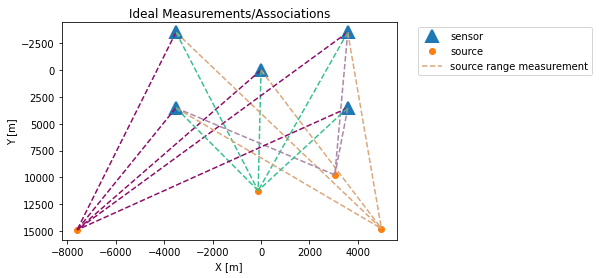

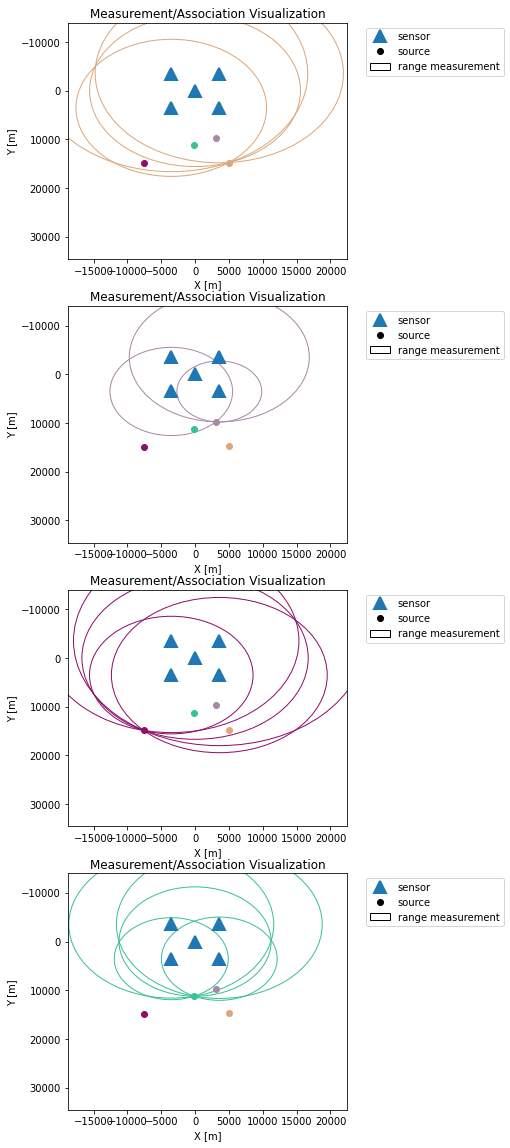

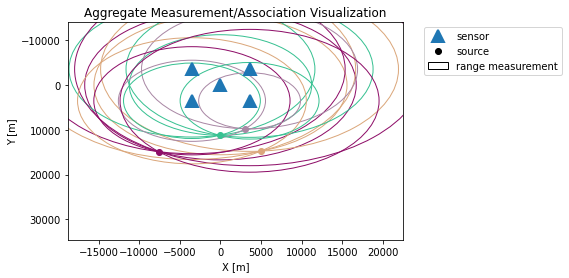

In [19]:
# generate measurements and associations
measurements, source_associations, TOSSIT_associations, source_locs = generate_measurements(num_sources=5, var=0, num_delete=1)

# visualize results
visualize_collection(measurements, TOSSIT_associations, source_associations, source_locs)
print(100*"=")
visualize_measurements(measurements, TOSSIT_associations, source_associations, source_locs)

### A RANSAC Approach
Using RANSAC to simultaneously perform data association and localization

In [102]:
def point_circle_shortest_distance(center, r, point):
    """
    Calculate shortest distance between a given point and circle
    """
    
    return np.abs(np.sqrt(((center - point) ** 2).sum()) - r)

def localize(sensors_idx, ranges, TOSSIT_locations, x0):
    """
    Perform localization given a set of measurements an associated sensors
    """
    
    # define localization objective
    def obj(x):
        # calculate l2s between TOSSIT positions and predicted location
        l2 = np.sqrt((TOSSIT_locations[sensors_idx,0] - x[0]) ** 2 + (TOSSIT_locations[sensors_idx,1] - x[1]) ** 2)

        # return sum squared error between l2s and predicted ranges
        return (1/3)*np.sum((l2.squeeze() - ranges) ** 2)
    
    # optimize
    return minimize(obj, x0, method='Nelder-Mead', options={'disp': False})
    

def RANSACish(measurements, n, alpha=50, beta=1000):
    
    # empty list for associations
    A = []
    
    # grab constants for sampling
    num_sensors = len(measurements)
    num_measurements = [len(m_set) for m_set in measurements]
    min_x = config['scaling']['min_x']
    max_x = config['scaling']['max_x']
    min_y = config['scaling']['min_y']
    max_y = config['scaling']['max_y']
    
    # load TOSSIT locations
    TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T
    
    for _ in tqdm(range(n)):
        
        # sample 3 sensors and one measurement from each
        s_samp = np.random.choice(num_sensors, replace=False, size=3)
        m_samp = [np.random.choice(num_measurements[s]) for s in s_samp]
        
        # get measurements
        r = [measurements[s][m] for s, m in zip(s_samp, m_samp)]
        
        # initial location guess
        x0 = [np.random.uniform(min_y, max_y), np.random.uniform(min_x, max_x)]
        
        # localize
        res = localize(s_samp, r, TOSSIT_locations, x0)
        cost = res.fun
        loc_est = res.x
        
        # if cost is above threshold, measurements are not consistent, otherwise
        # we assume that we have a set of 3 consistent measurements and keep going
        if np.sqrt(cost) > alpha:
            continue
        
        # check if any measurements from other sensors are sufficiently close to localized spot
        new_m = False
        for i, s in enumerate(measurements):
    
            # ignore sensors we've already sampled form
            if i in s_samp:
                continue
            
            # get current sensor location (1-1 correspondence with measurement idx)
            sensor_loc = TOSSIT_locations[i]
            
            for j, m in enumerate(s):
                
                # get shortest distance between measurement-defined circle and location prediction
                d = point_circle_shortest_distance(sensor_loc, m, loc_est)
                
                if d < beta:
                    s_samp = np.append(s_samp, i)
                    m_samp = np.append(m_samp, j)
                    r.append(m)
                    new_m = True
        
        # check if current association is a subset of a new association, and replace if so
        append = True
        sr = set(r)
        for i, a in enumerate(A):
            
            # if current ranges intersects with any saved set and is smaller we already have a better association
            # involving some subset of the ranges in common
            if len(set(a[0]).intersection(sr)) > 0 and len(r) <= len(a[0]):
                append = False
                break
            
            # check if current ranges are a larger consistent set one already stored involving them all
            if new_m and (set(a[0]).issubset(sr) or (len(set(a[0]).intersection(sr)) > 0 and len(r) >= len(a[0]))):
                A[i][0] = r
                A[i][1] = s_samp
                A[i][2] = loc_est
                append = False
        
        if append:
            A.append([r, s_samp, loc_est])
        
    return A

In [16]:
saves = RANSACish(measurements, 3500, alpha=200, beta=1000)

  0%|          | 0/3500 [00:00<?, ?it/s]

Convert results to format for visualization

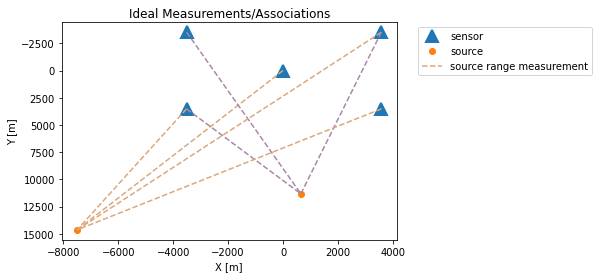

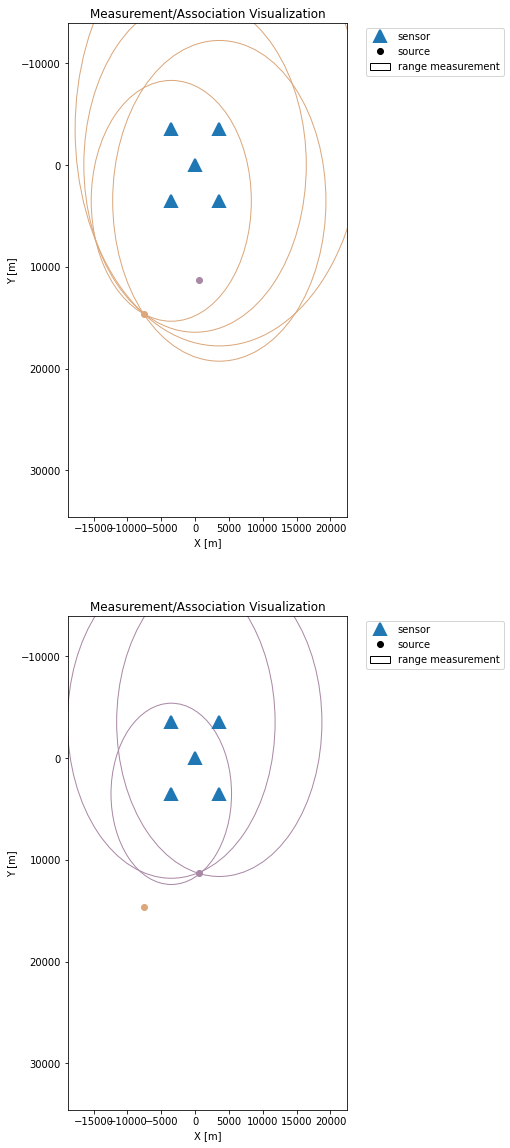

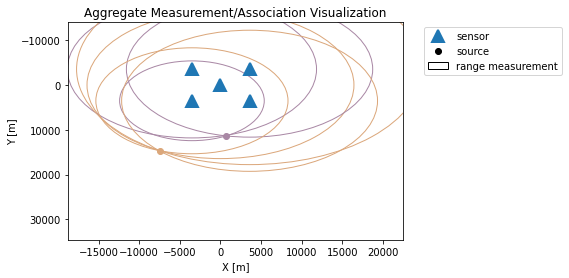

In [18]:
m_opt = [[] for _ in range(len(measurements))]
a_opt = [[] for _ in range(len(source_associations))]
t_opt = [[] for _ in range(len(measurements))]
l_opt = np.zeros((len(saves), 2))

a_num = 0
for s in saves:
    for m, t in zip(s[0], s[1]):
        m_opt[t].append(m)
        a_opt[t].append(a_num)
        t_opt[t].append(t)
    l_opt[a_num,:] = s[2]
    a_num += 1
    
m_opt = [np.asarray(elem) for elem in m_opt]
a_opt = [np.asarray(elem) for elem in a_opt]
t_opt = [np.asarray(elem) for elem in t_opt]

visualize_collection(m_opt, t_opt, a_opt, l_opt)
print(100*"=")
visualize_measurements(m_opt, t_opt, a_opt, l_opt)

### Graph-Based Approach

In [20]:
class Localizer:
    
    def __init__(self, k=3, thresh=5):
            
        # load TOSSIT locations
        self.TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T
        
        # initialize empty measurements and hypergraph
        self.measurements = None
        self.H = None
        self._linear_measurements = None
        
        # uniformity constant for hypergraph
        if k < 3:
            raise ValueError("k must be >= 3")
        else:
            self.k = k
        
        # threshold for measurement consistency
        self.thresh = thresh
        
        # get bounds of considered grid
        self.min_x = config['scaling']['min_x']
        self.max_x = config['scaling']['max_x']
        self.min_y = config['scaling']['min_y']
        self.max_y = config['scaling']['max_y']
    
    def _localize(self, ranges, sensors_idx):
        
        # define objective function
        def obj(x):
            # calculate l2s between TOSSIT positions and predicted location
            l2 = np.sqrt((self.TOSSIT_locations[sensors_idx,0] - x[0]) ** 2 + (self.TOSSIT_locations[sensors_idx,1] - x[1]) ** 2)

            # return sum squared error between l2s and predicted ranges
            return (1/self.k)*np.sum((l2.squeeze() - ranges) ** 2)
        
        # random initial guess
        x0 = [np.random.uniform(self.min_y, self.max_y), np.random.uniform(self.min_x, self.max_x)]
        
        # optimize!
        res = minimize(obj, x0, method='Nelder-Mead', options={'disp': False})
        
        return res.fun, res.x
    
    def set_measurements(self, measurements):
        
        # update measurements
        self.measurements = measurements
        
        ######################################################
        #               create formatted lists               #
        ######################################################
        
        # set of sensor indices with measurements
        non_empty_sensors = set()
        # list of all measurements traversed sensor-major
        self._linear_measurements = []
        # same shape as measurements but with linear indices
        formatted_linear_idx = [[] for _ in range(self.TOSSIT_locations.shape[0])]
        # measurement to linear index dict
        measurement_to_linear_idx = {}
        self._tuple_idx = []
        for i, m_list in enumerate(self.measurements):
            for j, m in enumerate(m_list):
                
                # keep track of sensors with measurements
                non_empty_sensors.add(i)
                
                # keep track of linear index
                linear_idx = len(self._linear_measurements)
                formatted_linear_idx[i].append(linear_idx)
                measurement_to_linear_idx[m] = linear_idx
                
                # keep linear list of measurements
                self._linear_measurements.append(m)
                
                self._tuple_idx.append((i, j))
                
        # convert linear_measurements to numpy array
        self._linear_measurements = np.asarray(self._linear_measurements)
        self._tuple_idx = np.asarray(self._tuple_idx)
        
        ######################################################
        #                  build hypergraph                  #
        ######################################################
        
        # get all combinations of sensor indices
        sensor_combs = itertools.combinations(non_empty_sensors, self.k)
        
        # for each group of k sensors, get valid measurement combination
        # candidates based on trilateration errors
        scenes = {}
        edge_set_counter = 0
        for s_comb in sensor_combs:
            
            # get range measurment indices associated with specified sensors in s_comb
            ranges = [formatted_linear_idx[sensor_idx] for sensor_idx in s_comb]
            
            # get all combinations of measurement indices across the sensors as List[List]
            range_combos = map(list, itertools.product(*ranges))
            
            # determine which candidates are consistent
            for range_combo in range_combos:
                
                # get trilateration cost for candidate
                cost, _ = self._localize(self._linear_measurements[range_combo], s_comb)
                
                if np.sqrt(cost) < self.thresh:
                    scenes[edge_set_counter] = range_combo
                    edge_set_counter += 1
        
        # save hypergraph
        self.H = hnx.Hypergraph(scenes)
        
    def associate_and_localize(self):
        
        # make sure we've set measurements
        assert self.measurements, "measurements have not been set"
        
        associations = []
        
        for h in self.H.connected_component_subgraphs():
            for clique in nx.find_cliques_recursive(h):
                if len(clique) >= self.k:
                    associations.append(clique)
        
        for a in associations:
            sensors = [self._tuple_idx[idx][0] for idx in a]
            ranges = self._linear_measurements[a]
            cost, loc = self._localize(ranges, sensors)
            print(loc)
        
        return associations

In [21]:
l = Localizer(k=3)

In [22]:
l.set_measurements(measurements)
l.associate_and_localize()

[14759.95083355  4968.50356518]
[14888.78076671 -7592.0542234 ]
[9765.64097926 3046.60106537]
[11228.2558447   -117.86368814]
[9781.44208795 3707.7962743 ]


[[0, 10, 3, 6], [1, 8, 4, 12, 15], [11, 14, 7], [5, 2, 16, 9, 13], [5, 14, 7]]

In [23]:
import hypernetx.algorithms.hypergraph_modularity as hmod
HG = hmod.precompute_attributes(l.H)
A = hmod.kumar(HG)
#hmod.last_step(HG, A, wdc=hmod.linear)
A

[{0, 3, 6, 10}, {1, 4, 8, 12, 15}, {2, 5, 9, 13, 16}, {7, 11, 14}]

In [24]:
HypernetxWidget(l.H)

HypernetxWidget(component='HypernetxWidget', props={'nodes': [{'uid': '7'}, {'uid': '6'}, {'uid': '14'}, {'uid…